### Album prediction


In [19]:
import os
from dotenv import load_dotenv
from pathlib import Path
import pandas as pd
import psycopg
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split

from sklearn.neighbors import NearestNeighbors

from sklearn.preprocessing import MultiLabelBinarizer
from scipy import sparse
import numpy as np
import pickle

In [2]:

# Load .env from parent directory
load_dotenv(dotenv_path=Path("../.env"))

# Connect
conn = psycopg.connect(
    dbname=os.getenv("DATABASE"),
    user=os.getenv("DB_USERNAME"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("POSTGRES"),
    port=5432
)

print(f"Connection successful")

query = """
SELECT DISTINCT release_group.id AS id, release_group.artist_credit AS artist_credit, release_group.type AS type, secondary_type AS sec_type, status, language , script, tag, count, genre.id AS genre_id, release_group_meta.first_release_date_year AS year
FROM release_group
LEFT JOIN release_group_secondary_type_join ON release_group.id = release_group_secondary_type_join.release_group
LEFT JOIN release ON release.release_group = release_group.id
LEFT JOIN release_tag ON release_tag.release = release.id
LEFT JOIN tag ON release_tag.tag = tag.id
LEFT JOIN genre ON genre.name = tag.name
LEFT JOIN release_group_meta ON release_group_meta.id = release_group.id """
data = pd.read_sql_query(query, conn)
conn.close()

Connection successful


/tmp/ipykernel_14905/2087082164.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  data = pd.read_sql_query(query, conn)


In [3]:
data.head()

,id,artist_credit,type,sec_type,status,language,script,tag,count,genre_id,year
0,2,1,1.0,1.0,1.0,120.0,28.0,NaN,NaN,NaN,2000.0
1,4,4,1.0,NaN,1.0,120.0,28.0,11.0,1.0,132.0,1991.0
2,4,4,1.0,NaN,1.0,120.0,28.0,12.0,1.0,115.0,1991.0
3,4,4,1.0,NaN,1.0,120.0,28.0,235.0,1.0,199.0,1991.0
4,4,4,1.0,NaN,1.0,120.0,28.0,267.0,1.0,343.0,1991.0


### Exploratory Data Analysis

In [4]:
data.dtypes

id                 int64
artist_credit      int64
type             float64
sec_type         float64
status           float64
language         float64
script           float64
tag              float64
count            float64
genre_id         float64
year             float64
dtype: object

In [5]:
data.dtypes.value_counts()

float64    9
int64      2
Name: count, dtype: int64

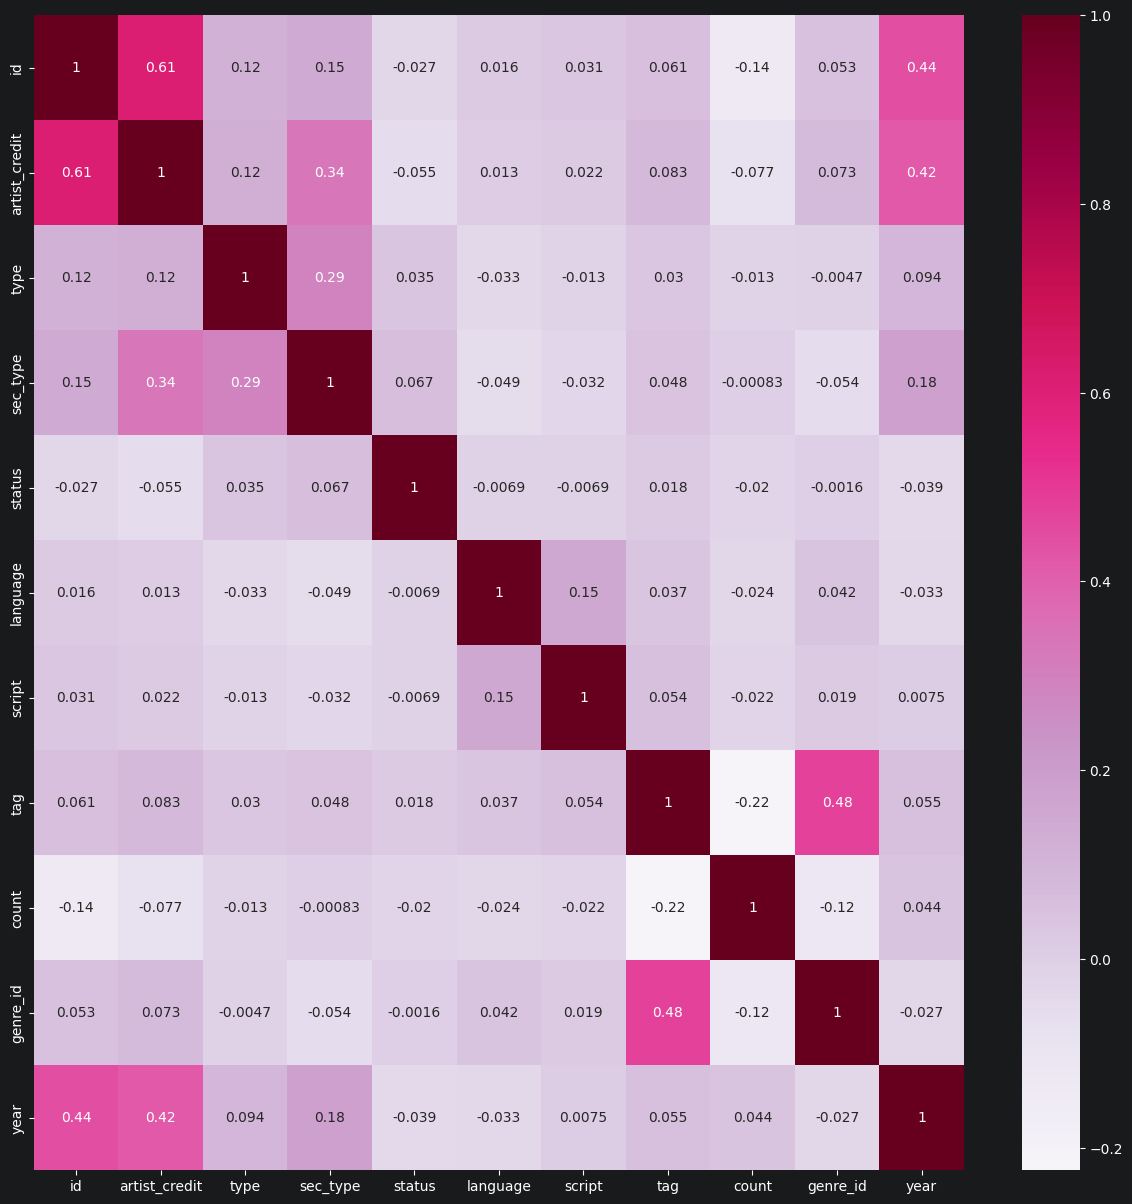

In [6]:
plt.figure(figsize = (15,15))
sns.heatmap(data.corr(numeric_only = True),
annot=True,
cmap="PuRd");

In [7]:
number_of_duplicated_rows = data.duplicated().sum()
number_of_duplicated_rows

np.int64(0)

### Set genre and tag as NaN if count is not positive

In [8]:
nan_count_pres = data['tag'].isna().sum()
cols_to_update = ['genre_id', 'tag']
data[cols_to_update] = data[cols_to_update].where(data['count'] > 0)
nan_count_post = data['tag'].isna().sum()
print(f"Removed {nan_count_post - nan_count_pres} downvoted genre")

Removed 15134 downvoted genre


In [9]:
data.isnull().mean().sort_values(ascending=False)

sec_type         0.815916
genre_id         0.753076
tag              0.558672
count            0.556608
script           0.141063
language         0.129208
status           0.045216
year             0.028908
type             0.019783
artist_credit    0.000000
id               0.000000
dtype: float64

### Grouping into 1 release_group

In [10]:

def most_common(series):
    """Return the most common non-null value in the series"""
    cleaned = series.dropna()
    if len(cleaned) == 0:
        return None
    return Counter(cleaned).most_common(1)[0][0]

def unique_list(series):
    """Return list of unique non-null values, preserving order"""
    seen = set()
    unique = []
    for val in series.dropna():
        if val not in seen:
            seen.add(val)
            unique.append(val)
    return unique

# Group by id
grouped = data.groupby('id').agg({
    'genre_id': unique_list,
    'tag': unique_list,
    'status': most_common,
    'language': most_common,
    'script': most_common,
    'type': most_common,
    # 'artist_credit': most_common,
}).reset_index()

In [11]:
sec_type_data = data.groupby('id')['sec_type'].first().reset_index()
type_data = data.groupby('id')['type'].first().reset_index()
year_data = data.groupby('id')['year'].first().reset_index()


grouped = grouped.merge(sec_type_data, on='id')
grouped = grouped.merge(type_data, on='id')
grouped = grouped.merge(year_data, on='id')
grouped

,id,genre_id,tag,status,language,script,type_x,sec_type,type_y,year
0,2,[],[],1.0,120.0,28.0,1.0,1.0,1.0,2000.0
1,4,"[132.0, 115.0, 199.0, 343.0, 158.0, 119.0, 370...","[11.0, 12.0, 235.0, 267.0, 303.0, 402.0, 609.0...",1.0,120.0,28.0,1.0,NaN,1.0,1991.0
2,11,"[222.0, 382.0, 1574.0]","[71.0, 1053.0, 6443.0, 111284.0]",1.0,120.0,28.0,1.0,NaN,1.0,1996.0
3,12,"[346.0, 14.0, 150.0, 42.0, 86.0, 90.0, 18.0]","[7.0, 20.0, 75.0, 127.0, 304.0, 564.0, 719.0, ...",1.0,120.0,28.0,1.0,NaN,1.0,2000.0
4,13,[],[],1.0,120.0,28.0,1.0,NaN,1.0,1995.0
...,...,...,...,...,...,...,...,...,...,...
4325761,4821676,[],[],1.0,198.0,85.0,1.0,NaN,1.0,2026.0
4325762,4821677,[],[],1.0,NaN,NaN,2.0,NaN,2.0,2026.0
4325763,4821678,[],[],1.0,120.0,28.0,2.0,NaN,2.0,2026.0
4325764,4821679,[],[],1.0,120.0,NaN,1.0,NaN,1.0,2015.0


In [12]:
grouped['sec_type'] = grouped['sec_type'].fillna(0)

In [13]:
X = grouped.drop(columns=["tag"])
X_train, X_test = train_test_split(
    X, test_size = 0.30, random_state = 2277
)

In [14]:
X_train.shape, X_test.shape

((3028036, 9), (1297730, 9))

### Preprocessing + modeling

In [15]:
def train_knn_from_grouped(grouped, n_neighbors=10, model_prefix="mb_knn", save_dir="../raw_data"):
    """
    Train a nearest-neighbors model and save everything to ONE .pkl file.
    """

    data_model = grouped.copy()

    # Feature columns: everything except id, tag, and artist_credit
    exclude_cols = ["id", "tag", "artist_credit"]
    feature_cols = [c for c in data_model.columns if c not in exclude_cols]

    if "genre_id" not in data_model.columns:
        raise ValueError("Missing required column: genre_id")

    # Ensure genre_id is always a list
    def ensure_list(x):
        if isinstance(x, list):
            return x
        if pd.isna(x):
            return []
        return [x]

    data_model["genre_id"] = data_model["genre_id"].apply(ensure_list)

    # Encode genre_id as sparse multilabel matrix
    genre_mlb = MultiLabelBinarizer(sparse_output=True)
    genre_sparse = genre_mlb.fit_transform(data_model["genre_id"])

    # Other numeric features (including year, NO artist_credit)
    other_cols = [c for c in feature_cols if c != "genre_id"]

    numeric_values = (
        data_model[other_cols]
        .fillna(0)
        .astype(np.float32)
        .to_numpy()
    )
    numeric_sparse = sparse.csr_matrix(numeric_values)

    # Final feature matrix
    X = sparse.hstack([genre_sparse, numeric_sparse], format="csr")

    # id -> row index mapping
    id_to_idx = {row_id: idx for idx, row_id in enumerate(data_model["id"])}

    # KNN
    knn = NearestNeighbors(
        n_neighbors=n_neighbors,
        metric="cosine",
        algorithm="brute"
    )
    knn.fit(X)

    # Create save directory if it doesn't exist
    save_path = Path(save_dir)
    save_path.mkdir(parents=True, exist_ok=True)

    # Save EVERYTHING to ONE pickle file
    bundle = {
        "knn": knn,
        "data_model": data_model,
        "genre_mlb": genre_mlb,
        "other_cols": other_cols,
        "id_to_idx": id_to_idx,
        "X": X,
        "feature_cols": feature_cols,
        "n_neighbors": n_neighbors,
    }

    pkl_path = save_path / f"{model_prefix}.pkl"
    with open(pkl_path, "wb") as f:
        pickle.dump(bundle, f)

    print(f"Features used: {feature_cols}")
    print(f"Numeric feature columns (including year, no artist_credit): {other_cols}")
    print(f"Model saved to: {pkl_path}")

    return bundle


In [16]:
# ----------------------------
# 2. LOAD SAVED OBJECTS (FROM SINGLE PKL FILE)
# ----------------------------

def load_knn_bundle(model_prefix="mb_knn", save_dir="../raw_data"):
    from pathlib import Path
    save_path = Path(save_dir)

    pkl_path = save_path / f"{model_prefix}.pkl"

    with open(pkl_path, "rb") as f:
        bundle = pickle.load(f)

    return bundle


# ----------------------------
# 3. BUILD FEATURE ROW FOR 1 ID
# ----------------------------

def build_feature_row(row_data, genre_mlb, other_cols):
    genre_sparse = genre_mlb.transform([row_data["genre_id"]])

    numeric_values = (
        row_data[other_cols]
        .fillna(0)
        .astype(np.float32)
        .to_numpy()
        .reshape(1, -1)
    )
    numeric_sparse = sparse.csr_matrix(numeric_values)

    X_row = sparse.hstack([genre_sparse, numeric_sparse], format="csr")
    return X_row


# ----------------------------
# 4. QUERY 1 ID
# ----------------------------

def find_similar_by_id(target_id, bundle, n_neighbors=None, exclude_self=False):
    knn = bundle["knn"]
    data_model = bundle["data_model"]
    genre_mlb = bundle["genre_mlb"]
    other_cols = bundle["other_cols"]
    id_to_idx = bundle["id_to_idx"]

    # Use parameter n_neighbors if provided, otherwise use bundle's default
    if n_neighbors is None:
        n_neighbors = bundle.get("n_neighbors", 10)

    if target_id not in id_to_idx:
        raise ValueError(f"ID {target_id} not found in dataset")

    row_idx = id_to_idx[target_id]
    row_data = data_model.iloc[row_idx]

    X_row = build_feature_row(row_data, genre_mlb, other_cols)

    distances, indices = knn.kneighbors(X_row, n_neighbors=n_neighbors)

    neighbors = data_model.iloc[indices[0]].copy()
    neighbors["distance"] = distances[0]
    neighbors["query_id"] = target_id

    if exclude_self:
        neighbors = neighbors[neighbors["id"] != target_id].reset_index(drop=True)

    return neighbors


# ----------------------------
# 5. QUERY A LIST OF IDS (RANDOMIZED ORDER)
# ----------------------------

def find_similar_by_ids_flat(target_ids, bundle, n_neighbors=None, exclude_self=False, seed=None):
    knn = bundle["knn"]
    data_model = bundle["data_model"]
    genre_mlb = bundle["genre_mlb"]
    other_cols = bundle["other_cols"]
    id_to_idx = bundle["id_to_idx"]

    # Use parameter n_neighbors if provided, otherwise use bundle's default
    if n_neighbors is None:
        n_neighbors = bundle.get("n_neighbors", 10)

    if seed is not None:
        random.seed(seed)

    all_results = []

    for target_id in target_ids:
        if target_id not in id_to_idx:
            print(f"Warning: ID {target_id} not found, skipping.")
            continue

        row_idx = id_to_idx[target_id]
        row_data = data_model.iloc[row_idx]

        X_row = build_feature_row(row_data, genre_mlb, other_cols)

        distances, indices = knn.kneighbors(X_row, n_neighbors=n_neighbors)

        neighbors = data_model.iloc[indices[0]].copy()
        neighbors["distance"] = distances[0]
        neighbors["query_id"] = target_id

        if exclude_self:
            neighbors = neighbors[neighbors["id"] != target_id]

        all_results.append(neighbors)

    if not all_results:
        return pd.DataFrame()

    result = pd.concat(all_results, ignore_index=True)

    # Randomize the order of the return list
    result = result.sample(frac=1, random_state=seed).reset_index(drop=True)

    return result


# ----------------------------
# 6. OPTIONAL CLEANUP FOR type_x / type_y
# ----------------------------

def clean_type_columns(df):
    df = df.copy()

    if "type_x" in df.columns and "type_y" in df.columns:
        df["type"] = df["type_x"]
        df = df.drop(columns=["type_x", "type_y"])
    elif "type_x" in df.columns:
        df = df.rename(columns={"type_x": "type"})
    elif "type_y" in df.columns:
        df = df.rename(columns={"type_y": "type"})

    return df

In [21]:
# Train and save to ONE .pkl file
bundle = train_knn_from_grouped(
    grouped=grouped,
    n_neighbors=10,
    model_prefix="album_knn",
    save_dir="../raw_data"
)

Features used: ['genre_id', 'status', 'language', 'script', 'type_x', 'sec_type', 'type_y', 'year']
Numeric feature columns (including year, no artist_credit): ['status', 'language', 'script', 'type_x', 'sec_type', 'type_y', 'year']
Model saved to: ../raw_data/album_knn.pkl


In [22]:
# Single id
similar_one = find_similar_by_id(
    target_id=12345,
    bundle=bundle,
    n_neighbors=10,
    exclude_self=True
)

similar_one = clean_type_columns(similar_one)

columns_to_show = [
    c for c in [
        "query_id", "id", "type", "year",
        "sec_type", "status", "language", "script", "distance"
    ] if c in similar_one.columns
]
similar_one[columns_to_show].head(10)

,query_id,id,type,year,sec_type,status,language,script,distance
0,12345,2076569,1.0,1993.0,0.0,1.0,120.0,28.0,0.0
1,12345,203555,1.0,1993.0,0.0,1.0,120.0,28.0,0.0
2,12345,343138,1.0,1993.0,0.0,1.0,120.0,28.0,0.0
3,12345,3024738,1.0,1993.0,0.0,1.0,120.0,28.0,0.0
4,12345,1380695,1.0,1993.0,0.0,1.0,120.0,28.0,0.0
5,12345,2532459,1.0,1993.0,0.0,1.0,120.0,28.0,0.0
6,12345,343279,1.0,1993.0,0.0,1.0,120.0,28.0,0.0
7,12345,938468,1.0,1993.0,0.0,1.0,120.0,28.0,0.0
8,12345,365394,1.0,1993.0,0.0,1.0,120.0,28.0,0.0
9,12345,1371368,1.0,1993.0,0.0,1.0,120.0,28.0,0.0


In [23]:

# List of ids (RANDOMIZED ORDER)
all_similar = find_similar_by_ids_flat(
    target_ids=[12345, 67890, 11111],
    bundle=bundle,
    n_neighbors=10,
    exclude_self=True,
    seed=None
)

all_similar = clean_type_columns(all_similar)

columns_to_show = [
    c for c in [
        "query_id", "id", "type", "year",
        "sec_type", "status", "language", "script", "distance"
    ] if c in all_similar.columns
]
all_similar[columns_to_show].head(30)

,query_id,id,type,year,sec_type,status,language,script,distance
0,67890,1823417,1.0,1957.0,0.0,1.0,120.0,28.0,0.0
1,12345,2532459,1.0,1993.0,0.0,1.0,120.0,28.0,0.0
2,67890,2464095,1.0,1957.0,0.0,1.0,120.0,28.0,0.0
3,67890,2112873,1.0,1957.0,0.0,1.0,120.0,28.0,0.0
4,12345,1380695,1.0,1993.0,0.0,1.0,120.0,28.0,0.0
5,67890,759209,1.0,1957.0,0.0,1.0,120.0,28.0,0.0
6,12345,343138,1.0,1993.0,0.0,1.0,120.0,28.0,0.0
7,12345,3024738,1.0,1993.0,0.0,1.0,120.0,28.0,0.0
8,12345,203555,1.0,1993.0,0.0,1.0,120.0,28.0,0.0
9,67890,2214211,1.0,1957.0,0.0,1.0,120.0,28.0,0.0
